<a href="https://colab.research.google.com/github/opendatas2017/NMC/blob/main/NMCourse_root_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Вычислени корней функций


In [ ]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from scipy import optimize

print("Numpy version is ",np.__version__)  # Должно показать версию, например 2.0.2

print("Python version is ",sys.version)

Numpy version is  2.0.2
Python version is  3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


## 1. Метод половинного деления (Бисекции)

Рассмотрим решение нелинейного уравнения $f(x) = 0$ на отрезке $[a, b]$.
Основная идея метода: если непрерывная функция меняет знак на концах отрезка ($f(a) \cdot f(b) < 0$), то корень находится внутри. Мы последовательно делим отрезок пополам и выбираем ту половину, где знак меняется.

**Цель:** Найти корень уравнения $x^3 - \cos(x) - 0.5 = 0$ на отрезке $[0, 2]$.

In [ ]:
import numpy as np

# --- 1. Определение целевой функции ---
def f(x: float) -> float:
    """
    Целевая функция f(x) = x^3 - cos(x) - 0.5
    """
    return x**3 - np.cos(x) - 0.5

# --- 2. Реализация метода бисекции ---
def bisection(a: float, b: float, tol: float = 1e-14, max_iter: int = 1000):
    """
    Поиск корня методом половинного деления.

    Параметры:
        a, b : границы начального интервала
        tol  : требуемая точность (длины интервала)
        max_iter : ограничение на число итераций (защита от бесконечного цикла)

    Возвращает:
        Приближенное значение корня
    """

    # Проверка условия сходимости: знаки на концах должны различаться
    if f(a) * f(b) >= 0:
        raise ValueError("Функция не меняет знак на концах отрезка. Корень может отсутствовать.")

    iteration = 0
    while (b - a) > tol:
        if iteration > max_iter:
            print("Предупреждение: достигнуто ограничение на число итераций.")
            break
        # Вычисляем середину интервала
        c = (a + b) / 2.0
        # Проверяем знак функции в середине и на левом конце
        if f(c) * f(a) > 0:
            # Знаки совпадают -> корень в правой половине [c, b]
            a = c
        else:
            # Знаки различаются -> корень в левой половине [a, c]
            b = c
        iteration += 1

    # Возвращаем середину финального интервала как оценку корня
    return (a + b) / 2.0

# --- 3. Запуск расчета ---
root = bisection(0., 2.)
print(f"Найденный корень: {root:.15f}")
print(f"Значение функции в корне: {f(root):.2e}")

Найденный корень: 1.010399064197859
Значение функции в корне: 1.33e-15


> **Ключевые выводы:**
> 1. **Надежность:** Метод гарантированно сходится, если функция непрерывна и знаки на концах отрезка различны.
> 2. **Скорость:** Сходимость линейная. На каждой итерации неопределенность уменьшается ровно в 2 раза. Это надежно, но медленно по сравнению с методом Ньютона.
> 3. **Критерий остановки:** Мы используем длину интервала $(b - a) < \varepsilon$. Это гарантирует, что истинный корень отличается от найденного не более чем на $\varepsilon$.

## 2. Модифицированный метод Ньютона: влияние параметра $\lambda$

Классический метод Ньютона можно представить как частный случай итерационного процесса:
$$x_{n+1} = x_n - \lambda \cdot f(x_n)$$

где $\varphi(x) = x - \lambda f(x)$ — функция итераций.

**Условие сходимости:** Процесс сходится, если $|\varphi'(x^*)| < 1$ в окрестности корня $x^*$.
Поскольку $\varphi'(x) = 1 - \lambda f'(x)$, оптимальный выбор $\lambda = \frac{1}{f'(x^*)}$ обращает производную в ноль, что обеспечивает квадратичную сходимость (классический метод Ньютона).

**Цель эксперимента:** Исследовать, как отклонение $\lambda_0$ от оптимального значения влияет на скорость сходимости метода.

Анализ сходимости в точке x* = 1.0:
- f'(x*) = 2.0
- Оптимальное lambda = 1/f'(x*) = 0.5
- Производная phi'(x*) = |1 - lambda*f'(x*)| = 0 (квадратичная сходимость)
--------------------------------------------------
✓ Точность |f(x)| < 1.0e-10 достигнута на итерации 4

Таблица итераций (lambda_0 = 0.5):
n            x_n       f(x_n)     |f(x_n)|
0     1.20000000     4.40e-01     4.40e-01
1     0.98000000    -3.96e-02     3.96e-02
2     0.99980000    -4.00e-04     4.00e-04
3     0.99999998    -4.00e-08     4.00e-08
4     1.00000000    -4.44e-16     4.44e-16


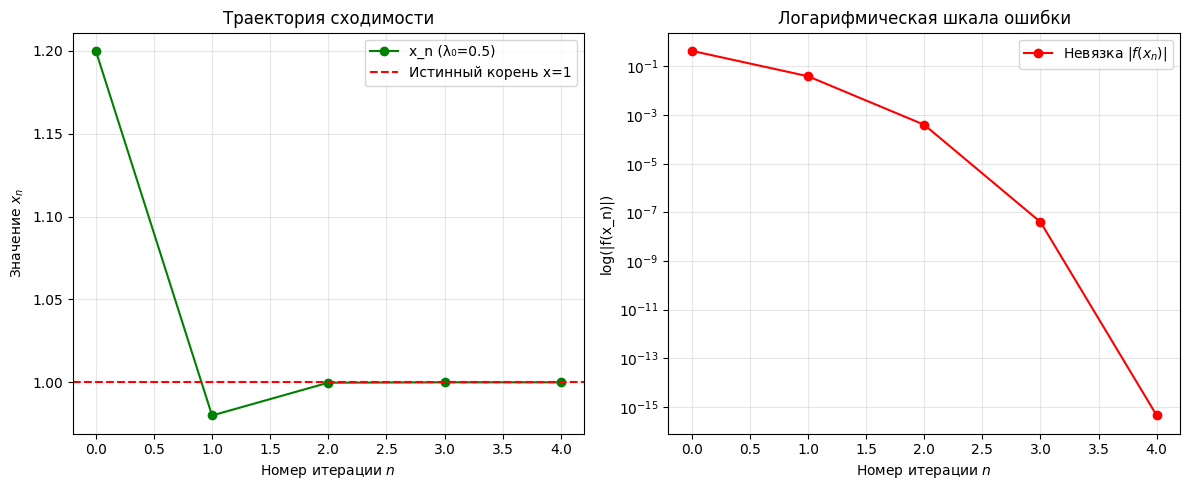


██████████████████████████████████████████████████████████████████████
  СРАВНЕНИЕ СХОДИМОСТИ ПРИ РАЗНЫХ ЗНАЧЕНИЯХ λ₀
██████████████████████████████████████████████████████████████████████
┌──────┬────────────┬─────────────────┬────────────┬───────────────┐
│   λ₀ │   Итераций │   Ошибка |f(x)| │   |φ'(x*)| │    Статус     │
├──────┼────────────┼─────────────────┼────────────┼───────────────┤
│  0.3 │         24 │        8.79e-11 │        0.4 │  ✅ Сходится  │
├──────┼────────────┼─────────────────┼────────────┼───────────────┤
│  0.5 │          4 │        4.44e-16 │        0   │  ✅ Сходится  │
├──────┼────────────┼─────────────────┼────────────┼───────────────┤
│  0.7 │         25 │        5.13e-11 │        0.4 │  ✅ Сходится  │
├──────┼────────────┼─────────────────┼────────────┼───────────────┤
│  1   │        100 │        0.133    │        1   │ ❌ Расходится │
└──────┴────────────┴─────────────────┴────────────┴───────────────┘
███████████████████████████████████████████████████████

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Реализация модифицированного метода Ньютона ---
def modified_newton(f, df, x0, lambda0, n_iter=20, tol=1e-10, verbose=True):
    """
    Итерационный метод поиска корня с фиксированным параметром lambda.

    Параметры:
        verbose : если False, подавляет вывод сообщений об итерациях
    """
    x = x0
    errors = [abs(f(x))]
    xs = [x]

    for i in range(n_iter):
        x_new = x - lambda0 * f(x)
        current_error = abs(f(x_new))

        x = x_new
        xs.append(x)
        errors.append(current_error)

        if current_error < tol:
            # Выводим сообщение только если включен режим verbose
            if verbose:
                print(f"✓ Точность |f(x)| < {tol:.1e} достигнута на итерации {i+1}")
            break

    return np.array(xs), np.array(errors)

# --- 2. Постановка тестовой задачи ---
# Уравнение: x^2 - 1 = 0, корни: x = ±1
f = lambda x: x**2 - 1
df = lambda x: 2*x

# --- 3. Выбор параметра lambda_0 ---
# Для квадратичной сходимости нужно lambda = 1/f'(корень)
root_approx = 1.0  # Работаем в окрестности корня x=1
lambda_optimal = 1 / df(root_approx)  # lambda_opt = 1/2 = 0.5

print(f"Анализ сходимости в точке x* = {root_approx}:")
print(f"- f'(x*) = {df(root_approx)}")
print(f"- Оптимальное lambda = 1/f'(x*) = {lambda_optimal}")
print(f"- Производная phi'(x*) = |1 - lambda*f'(x*)| = 0 (квадратичная сходимость)")
print("-" * 50)

# --- 4. Запуск расчета с оптимальным lambda ---
x0 = 1.2  # Начальное приближение
xs, errors = modified_newton(f, df, x0, lambda_optimal)

# Вывод таблицы итераций для детального разбора
print(f"\nТаблица итераций (lambda_0 = {lambda_optimal}):")
print(f"{'n':<3} {'x_n':>12} {'f(x_n)':>12} {'|f(x_n)|':>12}")
for i, (x_val, err_val) in enumerate(zip(xs, errors)):
    print(f"{i:<3} {x_val:12.8f} {f(x_val):12.2e} {err_val:12.2e}")

# --- 5. Визуализация результатов ---
plt.figure(figsize=(12, 5))

# График 1: Траектория приближений x_n
plt.subplot(1, 2, 1)
plt.plot(xs, 'go-', label=f'x_n (λ₀={lambda_optimal})', markersize=6)
plt.axhline(y=1, color='r', ls='--', lw=1.5, label='Истинный корень x=1')
plt.xlabel('Номер итерации $n$')
plt.ylabel('Значение $x_n$')
plt.title('Траектория сходимости')
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Логарифм ошибки (для оценки скорости сходимости)
plt.subplot(1, 2, 2)
plt.semilogy(errors, 'ro-', label='Невязка $|f(x_n)|$', markersize=6)
plt.xlabel('Номер итерации $n$')
plt.ylabel('log(|f(x_n)|)')
plt.title('Логарифмическая шкала ошибки')
plt.legend()
plt.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()
# --- 6. Сравнительный анализ разных lambda (Оформленный вывод) ---
print("\n" + "█"*70)
print("  СРАВНЕНИЕ СХОДИМОСТИ ПРИ РАЗНЫХ ЗНАЧЕНИЯХ λ₀")
print("█"*70)

# Попытка импортировать tabulate для красивых таблиц, если нет - используем запасной вариант
try:
    from tabulate import tabulate
    USE_TABULATE = True
except ImportError:
    USE_TABULATE = False

lambdas_to_test = [0.3, 0.5, 0.7, 1.0]
table_data = []

for lam in lambdas_to_test:
    # ВАЖНО: verbose=False, чтобы сообщения не ломали таблицу!
    xs_test, errors_test = modified_newton(f, df, x0, lam, n_iter=100, verbose=False)

    n_iters = len(xs_test) - 1
    final_error = errors_test[-1]

    # Определение статуса с эмодзи для наглядности
    if final_error < 1e-10:
        status = "✅ Сходится"
    elif n_iters >= 99:
        status = "❌ Расходится"
    else:
        status = "⚠️ Неточно"

    # Теоретический коэффициент сходимости q = |phi'(x*)|
    q_factor = abs(1 - lam * df(1.0))

    # Формируем строку данных
    table_data.append([
        f"{lam:.2f}",
        n_iters,
        f"{final_error:.2e}",
        f"{q_factor:.3f}",
        status
    ])

# Заголовки таблицы
headers = ["λ₀", "Итераций", "Ошибка |f(x)|", "|φ'(x*)|", "Статус"]

if USE_TABULATE:
    # Красивый вывод с помощью библиотеки
    print(tabulate(table_data, headers=headers, tablefmt="simple_grid", stralign="center"))
else:
    # Запасной вариант (ручное форматирование), если tabulate не установлен
    print(f"\n{headers[0]:<6} | {headers[1]:<10} | {headers[2]:<15} | {headers[3]:<10} | {headers[4]}")
    print("-" * 70)
    for row in table_data:
        print(f"{row[0]:<6} | {row[1]:<10} | {row[2]:<15} | {row[3]:<10} | {row[4]}")

print("█"*70)

> 🎯 **Анализ результатов:**
> 1. **Золотая середина ($\lambda=0.5$):** При $\lambda = 1/f'(x^*)$ коэффициент $|\varphi'(x^*)| \approx 0$. Это обеспечивает сверхбыструю сходимость (всего 4 итерации).
> 2. **Линейная сходимость ($\lambda=0.3, 0.7$):** При отклонении $\lambda$ от оптимума, $|\varphi'(x^*)| > 0$. Сходимость становится линейной (геометрическая прогрессия), что требует в 5-6 раз больше итераций.
> 3. **Граница устойчивости ($\lambda=1.0$):** Здесь $|\varphi'(x^*)| = 1$. Теорема о сходимости итераций не гарантирует результат. На практике метод «топчется на месте» и не достигает высокой точности.

## 3. Геометрическая интерпретация метода простой итерации

 уравнение $f(x) = 0$ можно привести к эквивалентному виду $x = g(x)$. Тогда итерационный процесс записывается как:
$$x_{n+1} = g(x_n)$$

**Геометрический смысл:**
На графике корень — это точка пересечения кривой $y = g(x)$ и биссектрисы $y = x$. Итерационный процесс можно представить как «лестницу» или «спираль», сходящуюся к точке пересечения.

**Скорость сходимости** зависит от угла наклона $g(x)$ в окрестности корня:
- Чем положе график $g(x)$ (ближе к горизонтали), тем быстрее сходимость.
- Если $|g'(x)| > 1$, итерации будут расходиться.

**Цель:** Сравнить три варианта функции $g(x)$ для уравнения $x^2 - 1 = 0$:
1. $g_1$ — Классический метод Ньютона.
2. $g_2$ — Модифицированный метод ($\lambda = 0.5$).
3. $g_3$ — Метод с малым шагом ($\lambda = 0.1$).

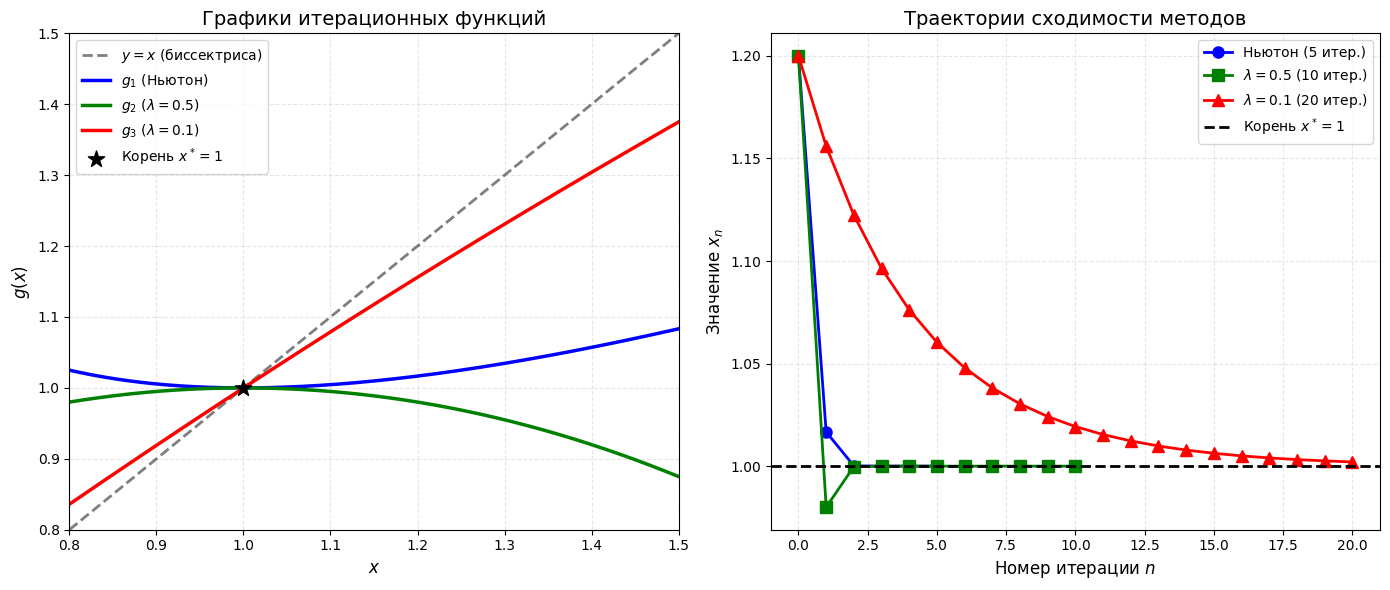


СРАВНЕНИЕ ТОЧНОСТИ ПОСЛЕ ИТЕРАЦИЙ
Метод                | Итераций   | x_n             | Ошибка |x_n - 1|
------------------------------------------------------------
Ньютон (g1)          | 5          | 1.0000000000    | 0.00e+00       
λ=0.5 (g2)           | 10         | 1.0000000000    | 0.00e+00       
λ=0.1 (g3)           | 20         | 1.0020491437    | 2.05e-03       


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Определение итерационных функций g(x) ---
# Исходное уравнение: f(x) = x^2 - 1
# Общий вид: g(x) = x - lambda * f(x)

def g1(x):
    """Метод Ньютона: lambda = 1/f'(x) = 1/(2x)
       g(x) = x - (x^2 - 1)/(2x) = (x + 1/x)/2
    """
    return x - (x**2 - 1) / (2 * x)

def g2(x):
    """Модифицированный метод Ньютона: lambda = 0.5 (фиксировано)
       g(x) = x - 0.5 * (x^2 - 1)
    """
    return x - 0.5 * (x**2 - 1)

def g3(x):
    """Метод с малым шагом: lambda = 0.1
       g(x) = x - 0.1 * (x^2 - 1)
    """
    return x - 0.1 * (x**2 - 1)

# --- 2. Реализация метода простой итерации ---
def iterate(g, x0, n_steps=10):
    """
    Выполняет n шагов итерационного процесса x_{n+1} = g(x_n).

    Параметры:
        g       : функция итерации
        x0      : начальное приближение
        n_steps : количество шагов

    Возвращает:
        Массив траектории [x0, x1, ..., xn]
    """
    x = x0
    trajectory = [x]

    for _ in range(n_steps):
        x = g(x)
        trajectory.append(x)

    return np.array(trajectory)

# --- 3. Запуск расчетов ---
x0 = 1.2  # Начальное приближение (справа от корня)

# Получаем траектории для всех трех методов
traj1 = iterate(g1, x0, n_steps=5)   # Ньютон (быстрая сходимость)
traj2 = iterate(g2, x0, n_steps=10)  # λ=0.5 (средняя скорость)
traj3 = iterate(g3, x0, n_steps=20)  # λ=0.1 (медленная сходимость)

# --- 4. Визуализация ---
x_plot = np.linspace(0.8, 1.5, 400)  # Область для построения графиков функций

plt.figure(figsize=(14, 6))

# График 1: Итерационные функции g(x)
plt.subplot(1, 2, 1)
plt.plot(x_plot, x_plot, 'k--', lw=2, label=r'$y = x$ (биссектриса)', alpha=0.5)
plt.plot(x_plot, g1(x_plot), 'b-', lw=2.5, label=r'$g_1$ (Ньютон)')
plt.plot(x_plot, g2(x_plot), 'g-', lw=2.5, label=r'$g_2$ ($\lambda=0.5$)')
plt.plot(x_plot, g3(x_plot), 'r-', lw=2.5, label=r'$g_3$ ($\lambda=0.1$)')

# Точка корня
plt.scatter([1], [1], c='black', s=150, zorder=5, marker='*', label='Корень $x^*=1$')

plt.xlabel('$x$', fontsize=12)
plt.ylabel('$g(x)$', fontsize=12)
plt.title('Графики итерационных функций', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0.8, 1.5)
plt.ylim(0.8, 1.5)

# График 2: Траектории сходимости x_n
plt.subplot(1, 2, 2)
plt.plot(traj1, 'bo-', label=r'Ньютон (5 итер.)', markersize=8, linewidth=2)
plt.plot(traj2, 'gs-', label=r'$\lambda=0.5$ (10 итер.)', markersize=8, linewidth=2)
plt.plot(traj3, 'r^-', label=r'$\lambda=0.1$ (20 итер.)', markersize=8, linewidth=2)

# Линия истинного корня
plt.axhline(y=1, color='k', ls='--', lw=2, label=r'Корень $x^*=1$')

plt.xlabel('Номер итерации $n$', fontsize=12)
plt.ylabel('Значение $x_n$', fontsize=12)
plt.title('Траектории сходимости методов', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


# --- 5. Вывод численных значений для анализа ---
print("\n" + "="*60)
print("СРАВНЕНИЕ ТОЧНОСТИ ПОСЛЕ ИТЕРАЦИЙ")
print("="*60)
print(f"{'Метод':<20} | {'Итераций':<10} | {'x_n':<15} | {'Ошибка |x_n - 1|':<15}")
print("-"*60)
print(f"{'Ньютон (g1)':<20} | {len(traj1)-1:<10} | {traj1[-1]:<15.10f} | {abs(traj1[-1]-1):<15.2e}")
print(f"{'λ=0.5 (g2)':<20} | {len(traj2)-1:<10} | {traj2[-1]:<15.10f} | {abs(traj2[-1]-1):<15.2e}")
print(f"{'λ=0.1 (g3)':<20} | {len(traj3)-1:<10} | {traj3[-1]:<15.10f} | {abs(traj3[-1]-1):<15.2e}")

> **Ключевые выводы:**
> 1. **Геометрия сходимости:**
>    - Метод Ньютона ($g_1$) имеет горизонтальную касательную в точке корня ($g'(x^*)=0$), поэтому он «прилипает» к корню быстрее всех.
>    - При уменьшении $\lambda$ график $g(x)$ становится круче, угол пересечения с биссектрисой увеличивается, и сходимость замедляется.
>
> 2. **Количество итераций:**
>    - Обратите внимание: для достижения схожей точности методу с $\lambda=0.1$ требуется в 4 раза больше итераций, чем методу Ньютона.
>
> 3. **Устойчивость:**
>    - Все три метода сходятся, так как $|g'(1)| < 1$ в окрестности корня.
>    - Если бы мы взяли $\lambda > 1$, то $|g'(1)| > 1$, и итерации начали бы расходиться (спираль раскручивалась бы).
>
> 4. **Визуализация:** Левый график показывает *почему* метод работает (пересечение с $y=x$), правый — *как быстро* он работает (крутизна спада ошибки).

## 4. Практическое применение: `scipy.optimize.newton`

Библиотека SciPy предоставляет универсальную функцию `optimize.newton`, которая автоматически выбирает алгоритм в зависимости от переданных параметров:

| Переданные параметры | Алгоритм | Сходимость |
|----------------------|----------|------------|
| Только $f(x)$ | Метод секущих | Линейная ($p \approx 1.618$) |
| $f(x) + f'(x)$ | Метод Ньютона | Квадратичная ($p = 2$) |
| $f(x) + f'(x) + f''(x)$ | Метод Халлея | Кубическая ($p = 3$) |

**Цель:** Решить уравнение $x^3 - 1 = 0$ тремя способами и сравнить количество итераций.

In [ ]:

# --- 1. Постановка задачи ---
# Уравнение: x^3 - 1 = 0
# Истинный корень: x* = 1
f = lambda x: x**3 - 1
df = lambda x: 3 * x**2
d2f = lambda x: 6 * x

x0 = 1.5  # Начальное приближение
tol = 1e-14  # Требуемая точность

print("="*60)
print("СРАВНЕНИЕ МЕТОДОВ В SCIPY.OPTIMIZE.NEWTON")
print("="*60)

# --- 2. Метод секущих (только f(x)) ---
# Требуется две начальные точки или одна (вторая вычисляется автоматически)
# Алгоритм: x_{n+1} = x_n - f(x_n) * (x_n - x_{n-1}) / (f(x_n) - f(x_{n-1}))
root_secant, info_secant = optimize.newton(
    f,
    x0=x0,
    x1=x0 * 1.1,      # Вторая точка для секущей
    tol=tol,
    full_output=True  # Возвращаем дополнительную информацию
)

print(f"\n1️⃣ Метод секущих (только f(x)):")
print(f"   Корень: {root_secant:.15f}")
print(f"   Итераций: {info_secant.iterations}")
print(f"   Невязка |f(x)|: {abs(f(root_secant)):.2e}")

# --- 3. Классический метод Ньютона (f(x) + f'(x)) ---
# Алгоритм: x_{n+1} = x_n - f(x_n) / f'(x_n)
root_newton, info_newton = optimize.newton(
    f,
    x0=x0,
    fprime=df,        # Передаем первую производную
    tol=tol,
    full_output=True
)

print(f"\n2️⃣ Метод Ньютона (f(x) + f'(x)):")
print(f"   Корень: {root_newton:.15f}")
print(f"   Итераций: {info_newton.iterations}")
print(f"   Невязка |f(x)|: {abs(f(root_newton)):.2e}")

# --- 4. Метод Халлея (f(x) + f'(x) + f''(x)) ---
# Алгоритм использует вторую производную для кубической сходимости
# x_{n+1} = x_n - (2*f*f') / (2*(f')^2 - f*f'')
root_halley, info_halley = optimize.newton(
    f,
    x0=x0,
    fprime=df,        # Первая производная
    fprime2=d2f,      # Вторая производная
    tol=tol,
    full_output=True
)

print(f"\n3️⃣ Метод Халлея (f(x) + f'(x) + f''(x)):")
print(f"   Корень: {root_halley:.15f}")
print(f"   Итераций: {info_halley.iterations}")
print(f"   Невязка |f(x)|: {abs(f(root_halley)):.2e}")

# --- 5. Визуальное сравнение эффективности ---
print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА ЭФФЕКТИВНОСТИ")
print("="*60)
print(f"{'Метод':<20} | {'Итераций':<10} | {'Порядок сходимости':<20}")
print("-"*60)
print(f"{'Секущих':<20} | {info_secant.iterations:<10} | {'p ≈ 1.618 (суперлин.)':<20}")
print(f"{'Ньютона':<20} | {info_newton.iterations:<10} | {'p = 2 (квадратичная)':<20}")
print(f"{'Халлея':<20} | {info_halley.iterations:<10} | {'p = 3 (кубическая)':<20}")
print("="*60)

СРАВНЕНИЕ МЕТОДОВ В SCIPY.OPTIMIZE.NEWTON

1️⃣ Метод секущих (только f(x)):
   Корень: 1.000000000000000
   Итераций: 9
   Невязка |f(x)|: 0.00e+00

2️⃣ Метод Ньютона (f(x) + f'(x)):
   Корень: 1.000000000000000
   Итераций: 6
   Невязка |f(x)|: 0.00e+00

3️⃣ Метод Халлея (f(x) + f'(x) + f''(x)):
   Корень: 1.000000000000000
   Итераций: 4
   Невязка |f(x)|: 0.00e+00

СВОДНАЯ ТАБЛИЦА ЭФФЕКТИВНОСТИ
Метод                | Итераций   | Порядок сходимости  
------------------------------------------------------------
Секущих              | 9          | p ≈ 1.618 (суперлин.)
Ньютона              | 6          | p = 2 (квадратичная)
Халлея               | 4          | p = 3 (кубическая)  


> **Ключевые выводы:**
> 1. **Автоматический выбор метода:** Функция `newton` умная — она сама переключает алгоритмы в зависимости от того, передали ли вы `fprime` и `fprime2`.
>
> 2. **Цена точности:**
>    - Метод Халлея требует меньше всего итераций, но на каждом шаге нужно вычислять **вторую производную**.
>    - Метод Ньютона — золотая середина для большинства задач.
>    - Метод секущих удобен, когда производную вычислить сложно или дорого, но сходимость медленнее.
>
> 3. **Практическая рекомендация:**
>    - Если есть аналитическая формула для $f'(x)$ — используйте метод Ньютона.
>    - Если $f'(x)$ неизвестна — метод секущих.
>    - Метод Халлея стоит применять только для задач, где вычисление второй производной дешево, а требуется экстремальная точность.
>
> 4. **Параметр `full_output=True`:** Всегда используйте его в учебных целях, чтобы видеть количество итераций и диагностировать проблемы сходимости.

## 5. Практическая задача: нелинейный резистор

**Физическая постановка:**
Рассмотрим цепь с нелинейным элементом, вольт-амперная характеристика которого задана как:
$$I(U) = 0.1 \cdot U + 0.01 \cdot U^3$$

Требуется найти напряжение $U$, при котором ток равен $I = 2$ А.

**Математическая модель:**
$$f(U) = I(U) - 2 = 0.01 \cdot U^3 + 0.1 \cdot U - 2 = 0$$

**Цель:** Сравнить работу методов Ньютона и секущих для решения инженерной задачи.

In [ ]:
from scipy.optimize import newton
import numpy as np

# --- 1. Физическая модель: нелинейный резистор ---
# ВАХ: I(U) = 0.1*U + 0.01*U^3 [А]
# Уравнение баланса: I(U) - I_target = 0

I_target = 2.0  # Целевой ток [А]

def residual_voltage(U):
    """
    Невязка уравнения: f(U) = I(U) - I_target
    Корень этого уравнения = искомое напряжение
    """
    return 0.1 * U + 0.01 * U**3 - I_target

def d_residual_dU(U):
    """
    Производная невязки: f'(U) = dI/dU
    Необходима для метода Ньютона
    """
    return 0.1 + 0.03 * U**2

print("⚡ ЗАДАЧА: Расчет напряжения в цепи с нелинейным резистором")
print(f"   Целевой ток: I = {I_target} А")
print(f"   Уравнение: 0.01·U³ + 0.1·U - {I_target} = 0")
print("-" * 60)

U_start = 10.0  # Начальное приближение [В]
tolerance = 1e-8  # Требуемая точность

# --- 2. Метод Ньютона (с аналитической производной) ---
# Преимущество: квадратичная сходимость
# Недостаток: нужно вычислять производную
U_newton, info_n = newton(
    residual_voltage,
    x0=U_start,
    fprime=d_residual_dU,
    tol=tolerance,
    full_output=True
)

print(f"\n✅ Метод Ньютона (с производной):")
print(f"   Напряжение: U = {U_newton:.6f} В")
print(f"   Итераций: {info_n.iterations}")
print(f"   Проверка: I(U) = {residual_voltage(U_newton) + I_target:.6f} А")

# --- 3. Метод секущих (без производной) ---
# Преимущество: не требует аналитической f'(x)
# Недостаток: медленнее сходится, нужны две начальные точки
U_secant, info_s = newton(
    residual_voltage,
    x0=U_start,
    x1=U_start * 1.2,  # Вторая точка для секущей
    tol=tolerance,
    full_output=True
)

print(f"\n✅ Метод секущих (без производной):")
print(f"   Напряжение: U = {U_secant:.6f} В")
print(f"   Итераций: {info_s.iterations}")
print(f"   Проверка: I(U) = {residual_voltage(U_secant) + I_target:.6f} А")

# --- 4. Сравнение и итоговая проверка ---
print("\n" + "=" * 60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 60)
print(f"Разница между методами: |U_newton - U_secant| = {abs(U_newton - U_secant):.2e} В")
print(f"Относительная погрешность: {abs(U_newton - U_secant)/U_newton * 100:.4f} %")

# Финальная валидация: подставляем найденное U в исходную формулу тока
def current_from_voltage(U):
    """Расчет тока по напряжению (прямая задача)"""
    return 0.1 * U + 0.01 * U**3

I_check = current_from_voltage(U_newton)
print(f"\n🔍 ФИНАЛЬНАЯ ПРОВЕРКА:")
print(f"   При U = {U_newton:.4f} В → I = {I_check:.6f} А")
print(f"   Отклонение от целевого: {abs(I_check - I_target):.2e} А {'✓' if abs(I_check - I_target) < 1e-6 else '✗'}")

⚡ ЗАДАЧА: Расчет напряжения в цепи с нелинейным резистором
   Целевой ток: I = 2.0 А
   Уравнение: 0.01·U³ + 0.1·U - 2.0 = 0
------------------------------------------------------------

✅ Метод Ньютона (с производной):
   Напряжение: U = 5.280022 В
   Итераций: 6
   Проверка: I(U) = 2.000000 А

✅ Метод секущих (без производной):
   Напряжение: U = 5.280022 В
   Итераций: 9
   Проверка: I(U) = 2.000000 А

СРАВНЕНИЕ РЕЗУЛЬТАТОВ
Разница между методами: |U_newton - U_secant| = 8.88e-16 В
Относительная погрешность: 0.0000 %

🔍 ФИНАЛЬНАЯ ПРОВЕРКА:
   При U = 5.2800 В → I = 2.000000 А
   Отклонение от целевого: 4.44e-16 А ✓


> **Ключевые выводы:**
> 1. **Инженерная интерпретация:** Численные методы позволяют решать задачи, где аналитическое решение кубического уравнения было бы громоздким.
>
> 2. **Выбор метода на практике:**
>    - Если производная $dI/dU$ известна и проста (как в этой задаче) — метод Ньютона эффективнее.
>    - Если функция задана экспериментально или через «черный ящик» — используем метод секущих.
>
> 3. **Важность проверки:** Всегда подставляйте найденный корень обратно в исходное уравнение! Это помогает отловить ошибки, особенно если функция имеет несколько корней или область определения ограничена.
>
> 4. **Начальное приближение:** В этой задаче $U_0 = 10$ В — разумная оценка. Если бы мы взяли $U_0 = 0$ или отрицательное значение, метод мог бы сойтись к другому корню (физически нереализуемому) или расходиться.

## 6. Корни многочленов и задача на собственные значения

**Теоретическая основа:**
Нахождение корней многочлена степени $n$:
$$P(x) = a_n x^n + a_{n-1} x^{n-1} + \dots + a_1 x + a_0 = 0$$

эквивалентно задаче поиска **собственных значений** специальной матрицы — Companion Matrix.

**Матрица :**
$$
C = \begin{pmatrix}
-\frac{a_{n-1}}{a_n} & -\frac{a_{n-2}}{a_n} & \dots & -\frac{a_0}{a_n} \\
1 & 0 & \dots & 0 \\
0 & 1 & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \dots & 0
\end{pmatrix}
$$

**Важно:** Функция `np.roots()` внутри себя строит именно эту матрицу и вычисляет её собственные значения через `np.linalg.eigvals()`. Это устойчивый численный метод для полиномов высокой степени.

**Цель:** Найти корни $P(x) = x^3 - 6x^2 + 11x - 6 = (x-1)(x-2)(x-3)$ двумя способами и сравнить результаты.

In [ ]:
import numpy as np

# --- 1. Задание многочлена ---
# P(x) = x^3 - 6x^2 + 11x - 6
# Ожидаемые корни: x = 1, 2, 3 (целые числа для проверки)
coeffs = [1, -6, 11, -6]  # Коэффициенты [a3, a2, a1, a0]

print("=" * 60)
print("НАХОЖДЕНИЕ КОРНЕЙ МНОГОЧЛЕНА ЧЕРЕЗ СОБСТВЕННЫЕ ЗНАЧЕНИЯ")
print("=" * 60)
print(f"Многочлен: P(x) = x³ - 6x² + 11x - 6")
print(f"Коэффициенты: {coeffs}")
print("-" * 60)

# --- 2. Способ 1: Встроенная функция np.roots() ---
# Это "черный ящик"
roots_numpy = np.roots(coeffs)

print("\n📊 Способ 1: np.roots() (библиотечная функция)")
print(f"Найденные корни: {roots_numpy}")
print(f"Тип данных: {roots_numpy.dtype}")

# --- 3. Способ 2: Явное построение матрицы  ---
n = len(coeffs) - 1  # Степень многочлена (для кубического n=3)
a_n = coeffs[0]      # Старший коэффициент (должен быть ≠ 0)

# Создаем матрицу  размера n×n
companion = np.zeros((n, n))

# Заполняем субдиагональ единицами (сдвиг на -1)
# Исправлено: np.ones(n-1) для корректного размера
companion += np.diag(np.ones(n-1), k=-1)

# Заполняем первую строку: -a_{n-1}/a_n, -a_{n-2}/a_n, ..., -a_0/a_n
companion[0, :] = -np.array(coeffs[1:]) / a_n

print(f"\n🔢 Способ 2: Матрица + собственные значения")
print("Матрица  C:")
print(companion)

# Вычисляем собственные значения матрицы
eigvals = np.linalg.eigvals(companion)


print(f"\nСобственные значения (корни): {eigvals}")


НАХОЖДЕНИЕ КОРНЕЙ МНОГОЧЛЕНА ЧЕРЕЗ СОБСТВЕННЫЕ ЗНАЧЕНИЯ
Многочлен: P(x) = x³ - 6x² + 11x - 6
Коэффициенты: [1, -6, 11, -6]
------------------------------------------------------------

📊 Способ 1: np.roots() (библиотечная функция)
Найденные корни: [3. 2. 1.]
Тип данных: float64

🔢 Способ 2: Матрица + собственные значения
Матрица  C:
[[  6. -11.   6.]
 [  1.   0.   0.]
 [  0.   1.   0.]]

Собственные значения (корни): [3. 2. 1.]


## 7. Метод Брента: надёжность + скорость

**Что такое метод Брента?**
Алгоритм Брента (1973) — это гибридный метод, который комбинирует три подхода:
1. **Метод половинного деления** (bisection) — гарантирует сходимость
2. **Метод секущих** (secant) — быстрая сходимость в хороших условиях
3. **Обратная квадратичная интерполяция** — ещё более быстрая сходимость

**Как это работает:**
- На каждой итерации алгоритм пытается сделать быстрый шаг (секущих или интерполяция)
- Если быстрый шаг ненадёжен (выходит за пределы отрезка или не уменьшает невязку) — делается шаг бисекции
- Это даёт **гарантированную сходимость** как у бисекции + **скорость** как у Ньютона

**Когда использовать:**
✅ Есть отрезок $[a, b]$ с разными знаками $f(a) \cdot f(b) < 0$
✅ Производная неизвестна или сложна для вычисления
✅ Нужна высокая надёжность без риска расходимости

**Функция в SciPy:** `scipy.optimize.brentq()`

In [ ]:
from scipy.optimize import brentq, bisect
import numpy as np

# --- 1. Постановка задачи ---
# Найти корень уравнения x^2 - 2 = 0 на отрезке [0, 2]
# Точный корень: sqrt(2) ≈ 1.4142135623730951

def func(x):
    """Целевая функция: f(x) = x^2 - 2"""
    return x**2 - 2

a, b = 0.0, 2.0  # Отрезок локализации корня
true_root = np.sqrt(2)  # Точное значение для сравнения

print("=" * 70)
print("МЕТОД БРЕНТА ПРОТИВ МЕТОДА ПОЛОВИННОГО ДЕЛЕНИЯ")
print("=" * 70)
print(f"Уравнение: x² - 2 = 0")
print(f"Отрезок: [{a}, {b}]")
print(f"Точный корень: √2 = {true_root:.15f}")
print(f"Проверка знаков: f({a}) = {func(a):.1f}, f({b}) = {func(b):.1f}")
print("-" * 70)

# --- 2. Метод Брента ---
# full_output=True возвращает дополнительную информацию о сходимости
root_brent, result_brent = brentq(
    func,
    a,
    b,
    xtol=1e-14,      # Точность по аргументу
    rtol=1e-14,      # Относительная точность
    full_output=True # Вернуть объект с информацией
)

print(f"\n🚀 МЕТОД БРЕНТА (brentq):")
print(f"   Найденный корень: {root_brent:.15f}")
print(f"   Погрешность: |x - √2| = {abs(root_brent - true_root):.2e}")
print(f"   Невязка |f(x)|: {abs(func(root_brent)):.2e}")
print(f"   Число итераций: {result_brent.iterations}")
print(f"   Число вызовов f(x): {result_brent.function_calls}")

# --- 3. Метод половинного деления (для сравнения) ---
root_bisect, result_bisect = bisect(
    func,
    a,
    b,
    xtol=1e-14,
    full_output=True
)

print(f"\n🐢 МЕТОД ПОЛОВИННОГО ДЕЛЕНИЯ (bisect):")
print(f"   Найденный корень: {root_bisect:.15f}")
print(f"   Погрешность: |x - √2| = {abs(root_bisect - true_root):.2e}")
print(f"   Невязка |f(x)|: {abs(func(root_bisect)):.2e}")
print(f"   Число итераций: {result_bisect.iterations}")
print(f"   Число вызовов f(x): {result_bisect.function_calls}")

# --- 4. Итоговое сравнение ---
print("\n" + "=" * 70)
print("СРАВНЕНИЕ ЭФФЕКТИВНОСТИ")
print("=" * 70)
print(f"{'Метод':<25} | {'Итераций':<10} | {'Вызовов f(x)':<13} | {'Погрешность':<15}")
print("-" * 70)
print(f"{'Брента':<25} | {result_brent.iterations:<10} | {result_brent.function_calls:<13} | {abs(root_brent - true_root):.2e}")
print(f"{'Половинного деления':<25} | {result_bisect.iterations:<10} | {result_bisect.function_calls:<13} | {abs(root_bisect - true_root):.2e}")
print("=" * 70)

# Выигрыш в итерациях
speedup = result_bisect.iterations / result_brent.iterations
print(f"\n💡 Метод Брента быстрее в {speedup:.1f} раз по числу итераций!")

МЕТОД БРЕНТА ПРОТИВ МЕТОДА ПОЛОВИННОГО ДЕЛЕНИЯ
Уравнение: x² - 2 = 0
Отрезок: [0.0, 2.0]
Точный корень: √2 = 1.414213562373095
Проверка знаков: f(0.0) = -2.0, f(2.0) = 2.0
----------------------------------------------------------------------

🚀 МЕТОД БРЕНТА (brentq):
   Найденный корень: 1.414213562373095
   Погрешность: |x - √2| = 2.22e-16
   Невязка |f(x)|: 4.44e-16
   Число итераций: 9
   Число вызовов f(x): 10

🐢 МЕТОД ПОЛОВИННОГО ДЕЛЕНИЯ (bisect):
   Найденный корень: 1.414213562373099
   Погрешность: |x - √2| = 4.22e-15
   Невязка |f(x)|: 1.20e-14
   Число итераций: 48
   Число вызовов f(x): 50

СРАВНЕНИЕ ЭФФЕКТИВНОСТИ
Метод                     | Итераций   | Вызовов f(x)  | Погрешность    
----------------------------------------------------------------------
Брента                    | 9          | 10            | 2.22e-16
Половинного деления       | 48         | 50            | 4.22e-15

💡 Метод Брента быстрее в 5.3 раз по числу итераций!


> **Ключевые выводы:**
> 1. **Гибридный подход:** Метод Брента автоматически выбирает лучшую стратегию на каждой итерации. Если функция «хорошая» — работает быстро как Ньютон, если «плохая» — надёжно как бисекция.
>
> 2. **Гарантия сходимости:** В отличие от метода Ньютона, Брент **всегда** сходится, если $f(a) \cdot f(b) < 0$. Это делает его методом выбора для производственного кода.
>
> 3. **Не требует производной:** Как и метод секущих, Брент работает только со значениями функции, что удобно для сложных или экспериментальных зависимостей.
>
> 4. **Практическая рекомендация:**
>    - Для 95% задач поиска корня на отрезке используйте `brentq()` — это оптимальный баланс скорости и надёжности.
>    - Метод Ньютона стоит применять только когда производная известна и нужна экстремальная скорость.
>    - Бисекцию используйте для учебных целей или когда важна предсказуемость числа итераций.
>
> 5. **Ограничение:** Требуется отрезок с разными знаками на концах. Если знак неизвестен — сначала нужно найти такой отрезок (например, перебором).

## 8. Универсальный интерфейс: `scipy.optimize.root_scalar`

**Что такое `root_scalar`?**
Начиная с SciPy 1.1.0, функция `root_scalar` предоставляет **единый интерфейс** для всех методов поиска корня скалярной функции.

**Преимущества перед отдельными функциями:**
| Аспект | Старый стиль (`brentq`, `bisect`) | Новый стиль (`root_scalar`) |
|--------|-----------------------------------|-----------------------------|
| API | Разные имена функций | Единая функция с параметром `method` |
| Возврат | Корень + доп. данные отдельно | Единый объект `sol` со всеми данными |
| Гибкость | Фиксированный набор параметров | Универсальные параметры для всех методов |

**Основные параметры:**
- `method` — название метода (`'brentq'`, `'bisect'`, `'newton'`, `'secant'`, `'halley'`, `'ridder'`)
- `bracket` — отрезок $[a, b]$ (требуется для методов, требующих локализации)
- `x0`, `x1` — начальные приближения (для методов типа Ньютона)
- `fprime` — первая производная (для Ньютона и Халлея)
- `fprime2` — вторая производная (для Халлея)

**Объект результата `sol`:**
- `sol.root` — найденный корень
- `sol.converged` — флаг успешной сходимости (True/False)
- `sol.iterations` — число итераций
- `sol.function_calls` — число вызовов функции
- `sol.flag` — код завершения

In [ ]:
from scipy.optimize import root_scalar
import numpy as np

# --- 1. Постановка задачи ---
# Найти корень уравнения x^2 - 2 = 0 (корень = √2)
def func(x):
    """Целевая функция: f(x) = x^2 - 2"""
    return x**2 - 2

def func_prime(x):
    """Первая производная: f'(x) = 2x"""
    return 2 * x

bracket = [0.0, 2.0]  # Отрезок локализации корня
x0 = 1.5              # Начальное приближение для методов без bracket

print("=" * 70)
print("СРАВНЕНИЕ МЕТОДОВ ЧЕРЕЗ root_scalar")
print("=" * 70)
print(f"Уравнение: x² - 2 = 0")
print(f"Точный корень: √2 = {np.sqrt(2):.15f}")
print("-" * 70)

# --- 2. Список методов для сравнения ---
methods_to_test = [
    {
        'name': 'brentq',
        'params': {'bracket': bracket},
        'description': 'Брента (гибридный)'
    },
    {
        'name': 'bisect',
        'params': {'bracket': bracket},
        'description': 'Половинного деления'
    },
    {
        'name': 'ridder',
        'params': {'bracket': bracket},
        'description': 'Риддера (эксп. интерполяция)'
    },
    {
        'name': 'newton',
        'params': {'x0': x0, 'fprime': func_prime},
        'description': 'Ньютона (с производной)'
    },
    {
        'name': 'secant',
        'params': {'x0': x0, 'x1': x0 * 1.1},
        'description': 'Секущих (без производной)'
    }
]

# --- 3. Запуск всех методов и сбор результатов ---
results = []

for method_info in methods_to_test:
    method_name = method_info['name']

    try:
        sol = root_scalar(
            func,
            method=method_name,
            xtol=1e-14,
            **method_info['params']
        )

        results.append({
            'method': method_info['description'],
            'root': sol.root,
            'converged': sol.converged,
            'iterations': sol.iterations,
            'function_calls': sol.function_calls,
            'error': abs(sol.root - np.sqrt(2))
        })

    except Exception as e:
        print(f"⚠️ Метод {method_name} не сошёлся: {e}")

# --- 4. Вывод сводной таблицы ---
print(f"\n{'Метод':<25} | {'Корень':<18} | {'Итер.':<6} | {'Вызовов':<8} | {'Погрешность':<12} | {'Статус':<8}")
print("-" * 90)

for res in results:
    status = "✓ OK" if res['converged'] else "✗ FAIL"
    print(f"{res['method']:<25} | {res['root']:<18.14f} | {res['iterations']:<6} | {res['function_calls']:<8} | {res['error']:.2e}       | {status:<8}")

print("-" * 90)
# --- 5. Детальная информация по лучшему методу ---
best_method = min(results, key=lambda x: x['iterations'])

print(f"\n🏆 ЛУЧШИЙ ПО ЧИСЛУ ИТЕРАЦИЙ: {best_method['method']}")
print(f"   Корень: {best_method['root']:.15f}")
print(f"   Итераций: {best_method['iterations']}")
print(f"   Погрешность: {best_method['error']:.2e}")

# Пример доступа к полному объекту решения
print("\n📋 ПРИМЕР: Полный объект решения для метода Брента")
# ИСПРАВЛЕНО: full_output=True не нужен, root_scalar всегда возвращает полный объект
sol_example = root_scalar(func, method='brentq', bracket=bracket)

print(f"   sol.root = {sol_example.root}")
print(f"   sol.converged = {sol_example.converged}")
print(f"   sol.iterations = {sol_example.iterations}")
print(f"   sol.function_calls = {sol_example.function_calls}")
print(f"   sol.flag = {sol_example.flag}")

СРАВНЕНИЕ МЕТОДОВ ЧЕРЕЗ root_scalar
Уравнение: x² - 2 = 0
Точный корень: √2 = 1.414213562373095
----------------------------------------------------------------------

Метод                     | Корень             | Итер.  | Вызовов  | Погрешность  | Статус  
------------------------------------------------------------------------------------------
Брента (гибридный)        | 1.41421356237309   | 9      | 10       | 2.22e-16       | ✓ OK    
Половинного деления       | 1.41421356237310   | 48     | 50       | 4.22e-15       | ✓ OK    
Риддера (эксп. интерполяция) | 1.41421356237309   | 6      | 14       | 1.11e-15       | ✓ OK    
Ньютона (с производной)   | 1.41421356237309   | 5      | 10       | 2.22e-16       | ✓ OK    
Секущих (без производной) | 1.41421356237309   | 6      | 7        | 2.22e-16       | ✓ OK    
------------------------------------------------------------------------------------------

🏆 ЛУЧШИЙ ПО ЧИСЛУ ИТЕРАЦИЙ: Ньютона (с производной)
   Корень: 1.4142135623730

> **Ключевые выводы:**
> 1. **Единый интерфейс:** `root_scalar` позволяет легко сравнивать разные методы, меняя только параметр `method`. Это удобно для прототипирования и исследования.
>
> 2. **Структурированный результат:** Объект `sol` содержит всю информацию о сходимости в одном месте. Всегда проверяйте `sol.converged` перед использованием `sol.root`!
>
> 3. **Выбор метода на практике:**
>    - **`brentq`** — лучший выбор по умолчанию (надёжность + скорость)
>    - **`bisect`** — если важна предсказуемость числа итераций
>    - **`newton`** — если известна производная и нужна максимальная скорость
>    - **`ridder`** — хорошая альтернатива Бренту, часто сходится быстрее
>    - **`secant`** — если производная неизвестна, но есть хорошее начальное приближение
>
> 4. **Параметры методов:** Обратите внимание, что разные методы требуют разных параметров:
>    - `bracket` — для методов, требующих отрезок локализации
>    - `x0`, `fprime` — для методов типа Ньютона
>
> 5. **Обработка ошибок:** Всегда оборачивайте вызов в `try-except` при автоматическом переборе методов — некоторые методы могут не сойтись на конкретной функции.



## Рекомендуемый метод



| Условия | Метод |
|---------|-------|
| Один корень, есть интервал | `brentq` |
|           | Самый надежный и быстрый для скаляров. |
| Один корень, нет интервала | `newton` |
|           | Быстрый, но нужно угадать точку старта. |
| Полиномы                     | `numpy.roots` |
|           |  уравнение вида $a_n x^n + \dots + a_0 = 0$. |

**Важно:** Для методов, требующих интервал (`brentq`, `bisect`), обязательно убедитесь, что $f(a)\cdot f(b) < 0$ (функция меняет знак на концах), иначе будет ошибка.